### Exploring dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)

print(df.dtypes)

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [2]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [3]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


TotalCharges    ->  object (it should be Float64)

In [5]:
# 1. See the exact Python type of the first few values
print(df['TotalCharges'].apply(type).unique())

[<class 'str'>]


### Fix type
<small>TotalCharges : object -> Float64

empty/wrong values -> NaN

In [6]:
# df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
# df['TotalCharges'] = df['TotalCharges'].astype('Float64')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].dtype)

float64


### Target Var : Churn

In [7]:
# Distribution
print(df['Churn'].value_counts(normalize=True))

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


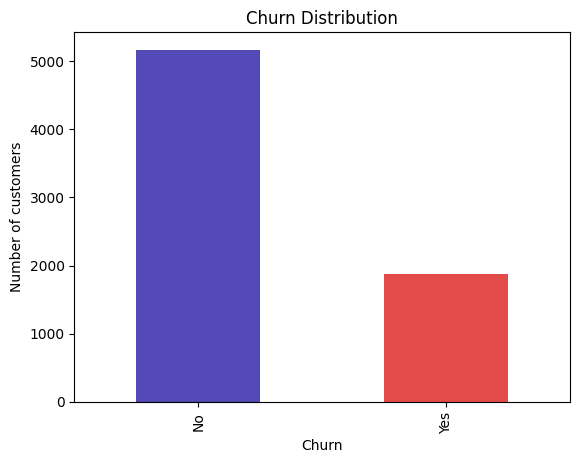

In [9]:
# Visualisation
df['Churn'].value_counts().plot(kind='bar', color=['#534AB7','#E24B4A'])
plt.title('Churn Distribution')
plt.ylabel('Number of customers')
plt.show()

Numerical features

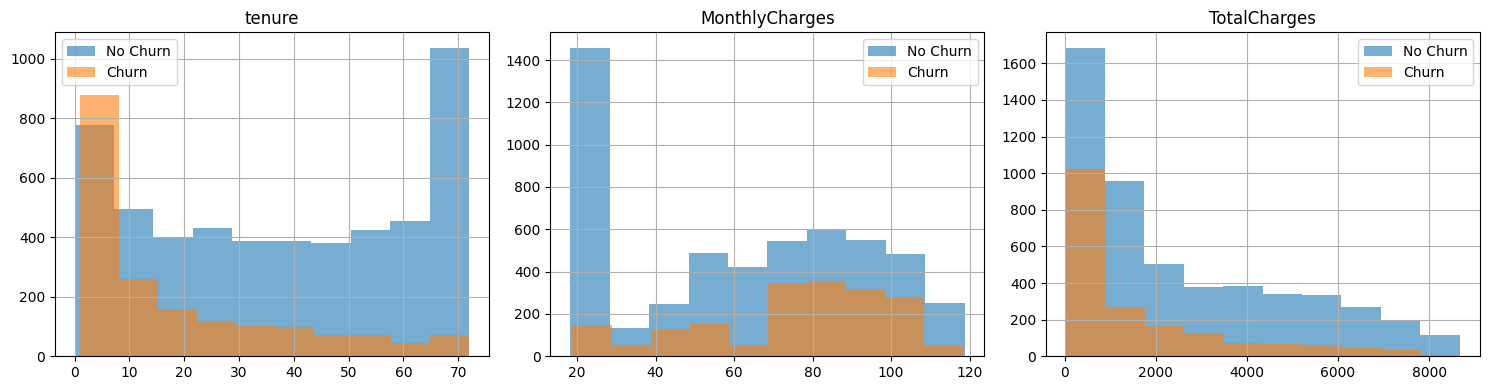

In [10]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# Distributions par Churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    df.groupby('Churn')[col].hist(alpha=0.6, ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

1. Churners are massively concentrated in the first months (0–10). 
Loyal customers (blue) have a big spike on the right around 70 months.
Conclusion: the more recent a customer is, the more likely they are to leave.

2. The orange is concentrated on the right (70–100$). 
Loyal customers have a massive spike on the left (~$20). 
Conclusion: customers who pay a lot churn more.

3. Orange is concentrated on the left (0–1000€). This is a direct consequence of tenure: churners leave early, so they have not had time to accumulate much.

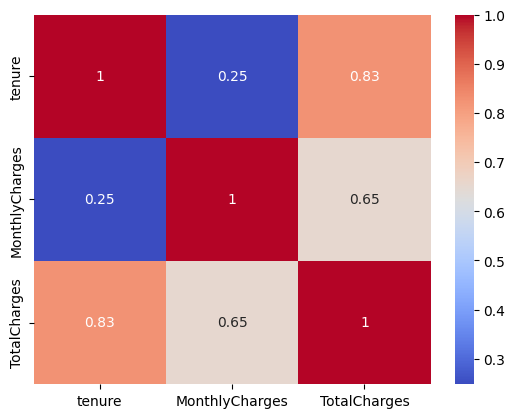

In [11]:
# Matrice de corrélation
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

Category features

In [14]:
#checking for outliers
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {n_out} outliers")

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


In [15]:
# Identifying categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', 'Churn']]

# Churn rate by category for each column
for col in cat_cols:
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean()
    ).round(3)
    print(f"\n{col}:")
    print(churn_rate.sort_values(ascending=False))


gender:
gender
Female    0.269
Male      0.262
Name: Churn, dtype: float64

Partner:
Partner
No     0.330
Yes    0.197
Name: Churn, dtype: float64

Dependents:
Dependents
No     0.313
Yes    0.155
Name: Churn, dtype: float64

PhoneService:
PhoneService
Yes    0.267
No     0.249
Name: Churn, dtype: float64

MultipleLines:
MultipleLines
Yes                 0.286
No                  0.250
No phone service    0.249
Name: Churn, dtype: float64

InternetService:
InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: Churn, dtype: float64

OnlineSecurity:
OnlineSecurity
No                     0.418
Yes                    0.146
No internet service    0.074
Name: Churn, dtype: float64

OnlineBackup:
OnlineBackup
No                     0.399
Yes                    0.215
No internet service    0.074
Name: Churn, dtype: float64

DeviceProtection:
DeviceProtection
No                     0.391
Yes                    0.225
No internet service    0.074
Name: Churn, dtype

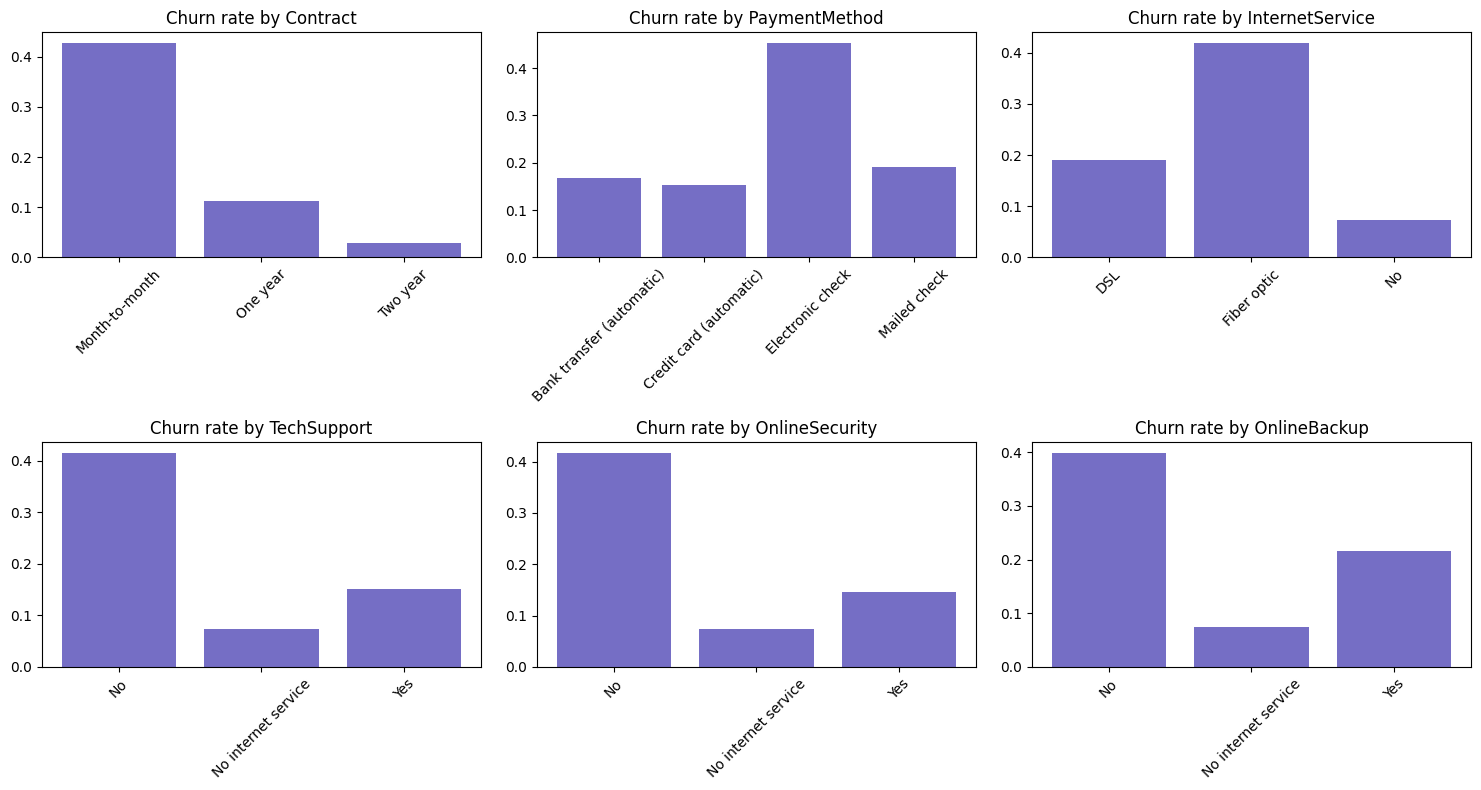

In [16]:
#keep relevant columns
cat_cols = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity', 'OnlineBackup']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x=='Yes').mean()
    ).reset_index()
    churn_rate.columns = [col, 'churn_rate']
    
    axes[i].bar(churn_rate[col], churn_rate['churn_rate'], 
                color='#534AB7', alpha=0.8)
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
#create a binary indicator column for automatic payments
df['auto_payment'] = df['PaymentMethod'].isin(
    ['Bank transfer (automatic)', 'Credit card (automatic)']
).astype(int)

In [18]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'auto_payment']


### Insights : Categorical Variables 
<small>A few features stand out clearly: 
- Contract : month-to-month customers churn at 43% vs only 3% for two-year contracts 
- PaymentMethod : electronic check (45%) vs automatic payments (~16%) 
- InternetService : fiber optic looks risky (42%) but it's probably because fiber customers tend to be on month-to-month contracts too

The real high-risk profile seems to be : fiber + no contract + high bill.
The model will need to capture this interaction.

## Summary: Key EDA Findings

1. **Contract type** is by far the strongest signal (43% vs 3%)
2. **tenure** : churners leave in the first 10 months
3. Paying by electronic check is a strong churn signal (45%)
4. TotalCharges and tenure are highly correlated (0.83) (one might be enough)
5. Gender has almost no impact → dropping it
6. No outliers in numerical features
7. 11 missing values in TotalCharges → converted to NaN with pd.to_numeric

In [19]:
#save 
df.to_csv('data/telco_clean.csv', index=False)

In [18]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Telco Churn Data", explorative=True)
profile.to_file("output_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 62.35it/s]
